# Exploratory Data Analysis

This notebook explores the Barcelona Airbnb dataset, from price distributions to neighbourhood-level patterns.

In [13]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

con = duckdb.connect("../data/warehouse.duckdb", read_only=True)
print("Connected. Tables:", con.execute("SHOW TABLES").fetchall())

Connected. Tables: [('dim_date',), ('dim_host',), ('dim_listing',), ('dim_neighbourhood',), ('fact_calendar',), ('fact_listing_performance',), ('fact_reviews',), ('stg_calendar',), ('stg_listings',), ('stg_neighbourhoods',), ('stg_reviews',), ('v_listing_demand',)]


## Price Distribution

All listings with valid price:
count    13355.000000
mean       240.616470
std        339.474553
min          3.500000
25%         89.290000
50%        177.670000
75%        285.500000
max      10542.220000
Name: price, dtype: float64

Active listings only:
count    9174.000000
mean      234.332086
std       185.428692
min        11.060000
25%       109.857500
50%       213.675000
75%       303.000000
max      4463.000000
Name: price, dtype: float64


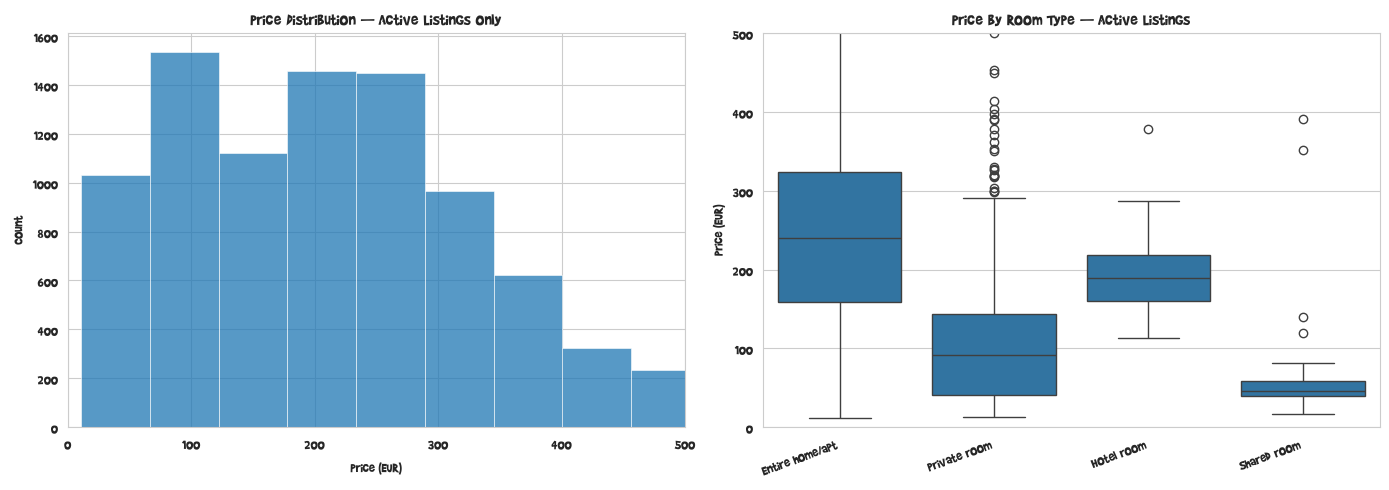

In [14]:
df_price = con.execute("""
    SELECT l.room_type, f.price, v.demand_segment
    FROM fact_listing_performance f
    JOIN dim_listing l ON f.listing_id = l.listing_id
    JOIN v_listing_demand v ON f.listing_id = v.listing_id
    WHERE f.price IS NOT NULL AND l.price_is_valid
""").df()

print("All listings with valid price:")
print(df_price['price'].describe())

print("\nActive listings only:")
print(df_price[df_price['demand_segment'] == 'active']['price'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
active_prices = df_price[df_price['demand_segment'] == 'active']

sns.histplot(active_prices['price'], bins=80, ax=axes[0])
axes[0].set_xlim(0, 500)
axes[0].set_title("Price Distribution — Active Listings Only")
axes[0].set_xlabel("Price (EUR)")

sns.boxplot(data=active_prices, x='room_type', y='price', ax=axes[1])
axes[1].set_ylim(0, 500)
axes[1].set_title("Price by Room Type — Active Listings")
axes[1].set_xlabel("")
axes[1].set_ylabel("Price (EUR)")
plt.setp(axes[1].get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.savefig("../reports/figures/price_distribution.png", dpi=150)
plt.show()

In [15]:
con.execute("""
    SELECT l.listing_id, l.room_type, l.accommodates, f.price
    FROM fact_listing_performance f
    JOIN dim_listing l ON f.listing_id = l.listing_id
    WHERE f.price IS NOT NULL AND l.price_is_valid
    ORDER BY f.price DESC
    LIMIT 10
""").df()

,listing_id,room_type,accommodates,price
0,867256504774715226,Entire home/apt,2,10542.22
1,1426637760045243370,Entire home/apt,16,7532.00
2,1405062163700981309,Entire home/apt,16,7293.00
3,1406454143054865483,Entire home/apt,16,6151.00
4,1400057633003120901,Entire home/apt,16,6106.00
5,1157205495486273795,Entire home/apt,16,5900.00
6,1309611159285218484,Entire home/apt,16,4885.00
7,909087702399642381,Entire home/apt,4,4463.00
8,1308738273720498469,Entire home/apt,16,4394.00
9,1473123174977324233,Entire home/apt,16,4080.00


In [16]:
con.execute("""
    SELECT listing_id, price, number_of_reviews, availability_365, estimated_occupancy_l365d
    FROM fact_listing_performance
    WHERE listing_id = 867256504774715226
""").df()

,listing_id,price,number_of_reviews,availability_365,estimated_occupancy_l365d
0,867256504774715226,10542.22,0,363,0


In [17]:
dormant = con.execute("""
    SELECT COUNT(*) AS dormant_count
    FROM fact_listing_performance
    WHERE number_of_reviews = 0 AND estimated_occupancy_l365d = 0
""").df()
print(dormant)

   dormant_count
0           3548


In [18]:
overlap = con.execute("""
    SELECT 
        COUNT(*) AS total,
        SUM(CASE WHEN number_of_reviews = 0 THEN 1 ELSE 0 END) AS zero_reviews,
        SUM(CASE WHEN estimated_occupancy_l365d = 0 THEN 1 ELSE 0 END) AS zero_occupancy,
        SUM(CASE WHEN number_of_reviews = 0 AND estimated_occupancy_l365d = 0 THEN 1 ELSE 0 END) AS both_zero
    FROM fact_listing_performance
""").df()
print(overlap)


   total  zero_reviews  zero_occupancy  both_zero
0  15293        3548.0          5627.0     3548.0


In [19]:
con.close()

In [20]:
con = duckdb.connect("../data/warehouse.duckdb", read_only=True)
segments = con.execute("SELECT demand_segment, COUNT(*) FROM v_listing_demand GROUP BY demand_segment").df()
print(segments)

         demand_segment  count_star()
0          never_active          3548
1                active          9666
2  dormant_with_history          2079


## Neighbourhood Price and Density Summary

In [21]:
geo = con.execute("""
    SELECT 
        l.neighbourhood_name,
        n.neighbourhood_group,
        COUNT(*) AS listing_count,
        ROUND(AVG(f.price), 2) AS avg_price,
        ROUND(MEDIAN(f.price), 2) AS median_price,
        ROUND(AVG(f.review_scores_rating), 2) AS avg_rating
    FROM fact_listing_performance f
    JOIN dim_listing l ON f.listing_id = l.listing_id
    JOIN v_listing_demand v ON f.listing_id = v.listing_id
    JOIN dim_neighbourhood n ON l.neighbourhood_name = n.neighbourhood_name
    WHERE v.demand_segment = 'active' AND l.price_is_valid
    GROUP BY l.neighbourhood_name, n.neighbourhood_group
    ORDER BY median_price DESC
""").df()

print(f"Total neighbourhoods: {len(geo)}")
print(geo.head(15))
print("\n--- Bottom 10 by median price ---")
print(geo.tail(10))

geo_reliable = geo[geo['listing_count'] >= 10].copy()
print(f"Neighbourhoods with n>=10: {len(geo_reliable)} (excluded {len(geo) - len(geo_reliable)} small-n neighbourhoods)")
print("\n--- Top 10 (reliable) ---")
print(geo_reliable.sort_values('median_price', ascending=False).head(10))
print("\n--- Bottom 10 (reliable) ---")
print(geo_reliable.sort_values('median_price', ascending=False).tail(10))

Total neighbourhoods: 67
                              neighbourhood_name  neighbourhood_group  \
0   Diagonal Mar i el Front Marítim del Poblenou           Sant Martí   
1                  la Vila Olímpica del Poblenou           Sant Martí   
2                                  el Fort Pienc             Eixample   
3                         la Dreta de l'Eixample             Eixample   
4                             la Sagrada Família             Eixample   
5                l'Antiga Esquerra de l'Eixample             Eixample   
6                                    Sant Antoni             Eixample   
7              el Parc i la Llacuna del Poblenou           Sant Martí   
8                                    el Poblenou           Sant Martí   
9                           el Putxet i el Farró  Sarrià-Sant Gervasi   
10                             la Vila de Gràcia               Gràcia   
11                la Nova Esquerra de l'Eixample             Eixample   
12                        

In [22]:
import json
with open("../data/raw/neighbourhoods.geojson") as f:
    geojson = json.load(f)
print(f"Number of features: {len(geojson['features'])}")
print("Sample feature properties:", geojson['features'][0]['properties'])

Number of features: 75
Sample feature properties: {'neighbourhood': 'el Raval', 'neighbourhood_group': 'Ciutat Vella'}


In [23]:
listing_neighbourhoods = set(geo['neighbourhood_name'])
geojson_neighbourhoods = set(f['properties']['neighbourhood'] for f in geojson['features'])
print(f"In geojson but no listings: {geojson_neighbourhoods - listing_neighbourhoods}")
print(f"In listings but no geojson boundary: {listing_neighbourhoods - geojson_neighbourhoods}")

In geojson but no listings: {'Vallbona', 'Diagonal Mar i el Front MarÃ\xadtim del Poblenou', 'la Clota', 'SarriÃ\xa0', 'la Vila de GrÃ\xa0cia', 'el CongrÃ©s i els Indians', 'Can Peguera', "el Camp d'en Grassot i GrÃ\xa0cia Nova", 'Can BarÃ³', 'el Barri GÃ²tic', 'Canyelles', 'la Sagrada FamÃ\xadlia', 'el GuinardÃ³', 'el Putxet i el FarrÃ³', 'BarÃ³ de Viver', 'Sant MartÃ\xad de ProvenÃ§als', 'el BesÃ²s i el Maresme', 'el Baix GuinardÃ³', 'la Vila OlÃ\xadmpica del Poblenou', 'el TurÃ³ de la Peira', 'Sant GenÃ\xads dels Agudells', 'Torre BarÃ³', 'ProvenÃ§als del Poblenou'}
In listings but no geojson boundary: {'el Besòs i el Maresme', 'la Vila de Gràcia', 'el Baix Guinardó', 'el Turó de la Peira', 'Provençals del Poblenou', 'la Vila Olímpica del Poblenou', 'el Guinardó', 'el Barri Gòtic', 'el Congrés i els Indians', 'Sant Genís dels Agudells', 'Can Baró', 'Diagonal Mar i el Front Marítim del Poblenou', 'Sarrià', "el Camp d'en Grassot i Gràcia Nova", 'la Sagrada Família', 'el Putxet i el Fa

In [24]:
bcn = con.execute("""
    SELECT l.room_type, COUNT(*) AS n, ROUND(AVG(f.price),2) AS avg_price, ROUND(MEDIAN(f.price),2) AS median_price
    FROM fact_listing_performance f
    JOIN dim_listing l ON f.listing_id = l.listing_id
    JOIN v_listing_demand v ON f.listing_id = v.listing_id
    WHERE l.neighbourhood_name = 'la Barceloneta' AND v.demand_segment = 'active' AND l.price_is_valid
    GROUP BY l.room_type
    ORDER BY n DESC
""").df()
print(bcn)

         room_type    n  avg_price  median_price
0  Entire home/apt  210     153.35         88.86
1     Private room   35     110.56        102.71


In [25]:
import json

with open("../data/raw/neighbourhoods.geojson", encoding="latin-1") as f:
    geojson = json.load(f)
print(geojson['features'][0]['properties'])

print(geojson['features'][0]['properties'])
listing_neighbourhoods = set(geo['neighbourhood_name'])
geojson_neighbourhoods = set(f['properties']['neighbourhood'] for f in geojson['features'])
print(f"Still mismatched: {geojson_neighbourhoods - listing_neighbourhoods}")

{'neighbourhood': 'el Raval', 'neighbourhood_group': 'Ciutat Vella'}
{'neighbourhood': 'el Raval', 'neighbourhood_group': 'Ciutat Vella'}
Still mismatched: {'Vallbona', 'Diagonal Mar i el Front MarÃ\xadtim del Poblenou', 'la Clota', 'SarriÃ\xa0', 'la Vila de GrÃ\xa0cia', 'el CongrÃ©s i els Indians', 'Can Peguera', "el Camp d'en Grassot i GrÃ\xa0cia Nova", 'Can BarÃ³', 'el Barri GÃ²tic', 'Canyelles', 'la Sagrada FamÃ\xadlia', 'el GuinardÃ³', 'el Putxet i el FarrÃ³', 'BarÃ³ de Viver', 'Sant MartÃ\xad de ProvenÃ§als', 'el BesÃ²s i el Maresme', 'el Baix GuinardÃ³', 'la Vila OlÃ\xadmpica del Poblenou', 'el TurÃ³ de la Peira', 'Sant GenÃ\xads dels Agudells', 'Torre BarÃ³', 'ProvenÃ§als del Poblenou'}


In [26]:
with open("../data/raw/neighbourhoods.geojson", "rb") as f:
    raw = f.read()

# Find "Putxet" and show the raw bytes right after it
idx = raw.find(b"Putxet")
print(raw[idx:idx+30])

b'Putxet i el Farr\xc3\xb3","neighbour'


In [27]:
bcn_detail = con.execute("""
    SELECT f.price
    FROM fact_listing_performance f
    JOIN dim_listing l ON f.listing_id = l.listing_id
    JOIN v_listing_demand v ON f.listing_id = v.listing_id
    WHERE l.neighbourhood_name = 'la Barceloneta' 
      AND l.room_type = 'Entire home/apt'
      AND v.demand_segment = 'active' AND l.price_is_valid
""").df()
print(bcn_detail['price'].describe())

count     210.000000
mean      153.346333
std       167.304660
min        41.130000
25%        69.455000
50%        88.855000
75%       206.125000
max      1826.000000
Name: price, dtype: float64


In [28]:
with open("../data/raw/neighbourhoods.geojson", encoding="utf-8") as f:
    geojson = json.load(f)

test_name = "el Putxet i el Farró"  # typed directly, should match exactly
geojson_names = set(f['properties']['neighbourhood'] for f in geojson['features'])

print(f"Direct match test: {test_name in geojson_names}")

listing_neighbourhoods = set(geo['neighbourhood_name'])
mismatch = geojson_names - listing_neighbourhoods
print(f"True mismatch count: {len(mismatch)}")

Direct match test: True
True mismatch count: 6


In [29]:
print(mismatch)

{'Vallbona', 'Canyelles', 'Can Peguera', 'la Clota', 'Torre Baró', 'Baró de Viver'}


(75, 3)
['neighbourhood', 'neighbourhood_group', 'geometry']
Merged shape: (52, 9)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_30988\4250689977.py:24: UserWarning: Glyph 8805 (\N{GREATER-THAN OR EQUAL TO}) missing from font(s) Brady Bunch.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_30988\4250689977.py:25: UserWarning: Glyph 8805 (\N{GREATER-THAN OR EQUAL TO}) missing from font(s) Brady Bunch.
  plt.savefig("../reports/figures/price_choropleth.png", dpi=150)
c:\Users\ASUS\Downloads\EXPERNETIC\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8805 (\N{GREATER-THAN OR EQUAL TO}) missing from font(s) Brady Bunch.
  fig.canvas.print_figure(bytes_io, **kw)


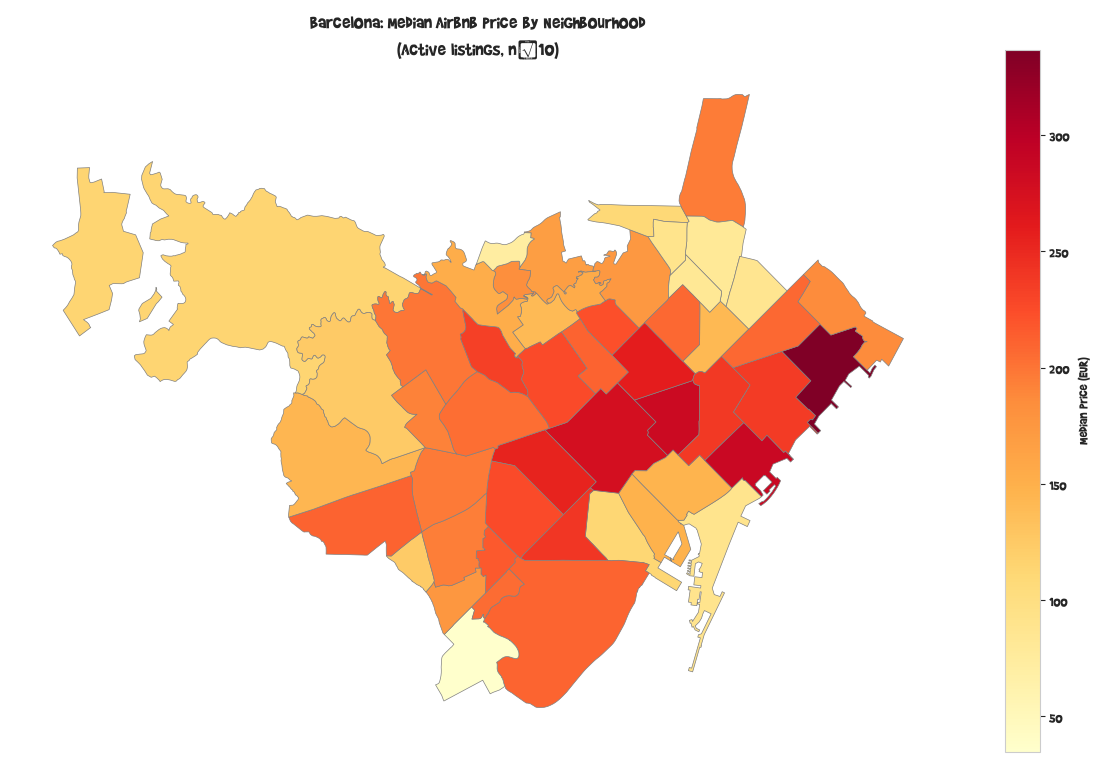

In [30]:
import geopandas as gpd

# Load boundaries
gdf = gpd.read_file("../data/raw/neighbourhoods.geojson")
print(gdf.shape)
print(gdf.columns.tolist())

# Merge with our reliable (n>=10) price data
gdf_merged = gdf.merge(geo_reliable, left_on='neighbourhood', right_on='neighbourhood_name', how='inner')
print(f"Merged shape: {gdf_merged.shape}")

fig, ax = plt.subplots(1, 1, figsize=(12, 12))
gdf_merged.plot(
    column='median_price',
    cmap='YlOrRd',
    linewidth=0.5,
    edgecolor='grey',
    legend=True,
    legend_kwds={'label': 'Median Price (EUR)', 'shrink': 0.6},
    ax=ax
)
ax.set_title("Barcelona: Median Airbnb Price by Neighbourhood\n(Active listings, n≥10)", fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.savefig("../reports/figures/price_choropleth.png", dpi=150)
plt.show()

In [31]:
review_trend = con.execute("""
    SELECT 
        EXTRACT(year FROM date) AS year,
        EXTRACT(month FROM date) AS month,
        COUNT(*) AS review_count
    FROM fact_reviews
    GROUP BY year, month
    ORDER BY year, month
""").df()

print(review_trend.tail(24))  # last 2 years for readability
print(f"\nTotal date range: {review_trend.iloc[0]['year']:.0f}-{review_trend.iloc[0]['month']:.0f} to {review_trend.iloc[-1]['year']:.0f}-{review_trend.iloc[-1]['month']:.0f}")

     year  month  review_count
163  2024      8         14361
164  2024      9         14390
165  2024     10         14948
166  2024     11         13186
167  2024     12         11007
168  2025      1         12144
169  2025      2         12596
170  2025      3         14639
171  2025      4         15219
172  2025      5         17165
173  2025      6         17257
174  2025      7         16791
175  2025      8         17181
176  2025      9         16542
177  2025     10         18000
178  2025     11         15782
179  2025     12         13047
180  2026      1         14163
181  2026      2         15501
182  2026      3         17577
183  2026      4         19537
184  2026      5         22321
185  2026      6         12284
186  2026      7             5

Total date range: 2010-10 to 2026-7


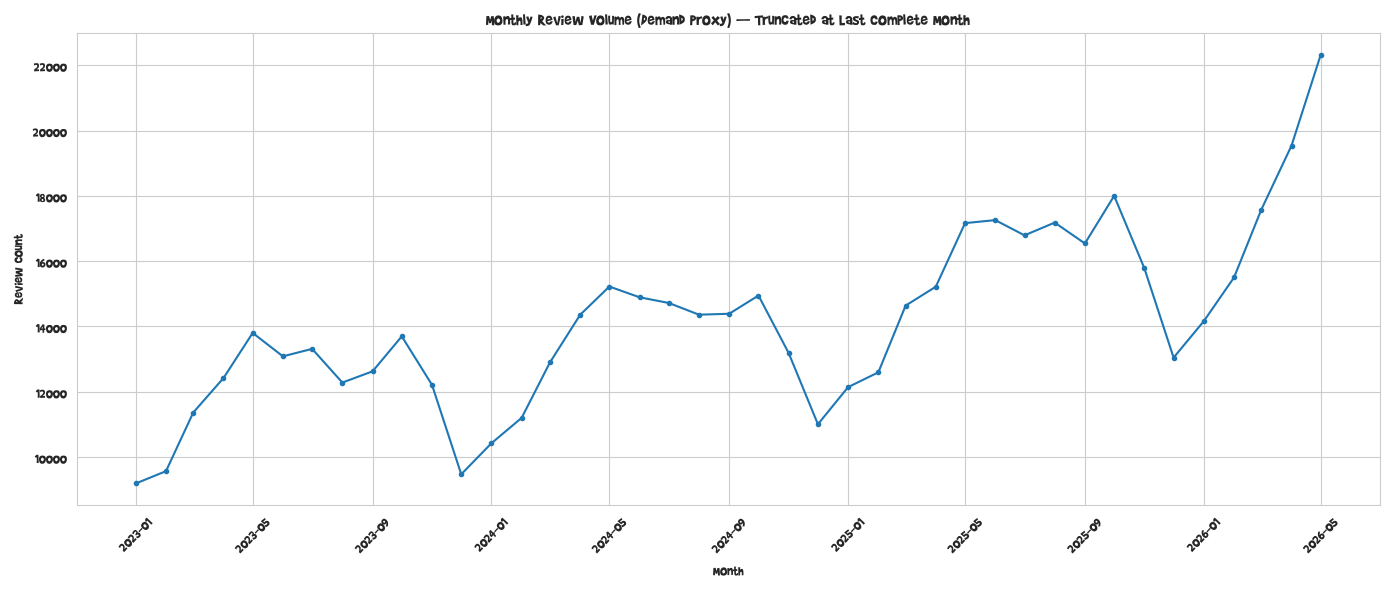

month
1     4362.0
2     4983.0
3     5424.0
4     5916.0
5     6678.0
6     5630.0
7     5930.0
8     5800.0
9     5824.0
10    5830.0
11    5208.0
12    4171.0
Name: review_count, dtype: float64


In [32]:
review_trend_clean = review_trend[
    (review_trend['year'] < 2026) | ((review_trend['year'] == 2026) & (review_trend['month'] <= 5))
].copy()
review_trend_clean['period'] = pd.to_datetime(
    review_trend_clean['year'].astype(int).astype(str) + '-' + review_trend_clean['month'].astype(int).astype(str) + '-01'
)

# Focus on last 3 full years for readability
recent = review_trend_clean[review_trend_clean['period'] >= '2023-01-01']

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(recent['period'], recent['review_count'], marker='o', markersize=3)
ax.set_title("Monthly Review Volume (Demand Proxy) — Truncated at Last Complete Month")
ax.set_xlabel("Month")
ax.set_ylabel("Review Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/figures/review_trend.png", dpi=150)
plt.show()

# Seasonality: average by calendar month across all complete years
seasonality = review_trend_clean.groupby('month')['review_count'].mean().round(0)
print(seasonality)

In [33]:
avail_by_month = con.execute("""
    SELECT 
        EXTRACT(month FROM date) AS month,
        AVG(CASE WHEN available THEN 1 ELSE 0 END) AS pct_available
    FROM fact_calendar
    GROUP BY month
    ORDER BY month
""").df()
print(avail_by_month)

    month  pct_available
0       1       0.640622
1       2       0.630095
2       3       0.609627
3       4       0.546681
4       5       0.529565
5       6       0.439874
6       7       0.376204
7       8       0.550543
8       9       0.607552
9      10       0.639517
10     11       0.706600
11     12       0.711745


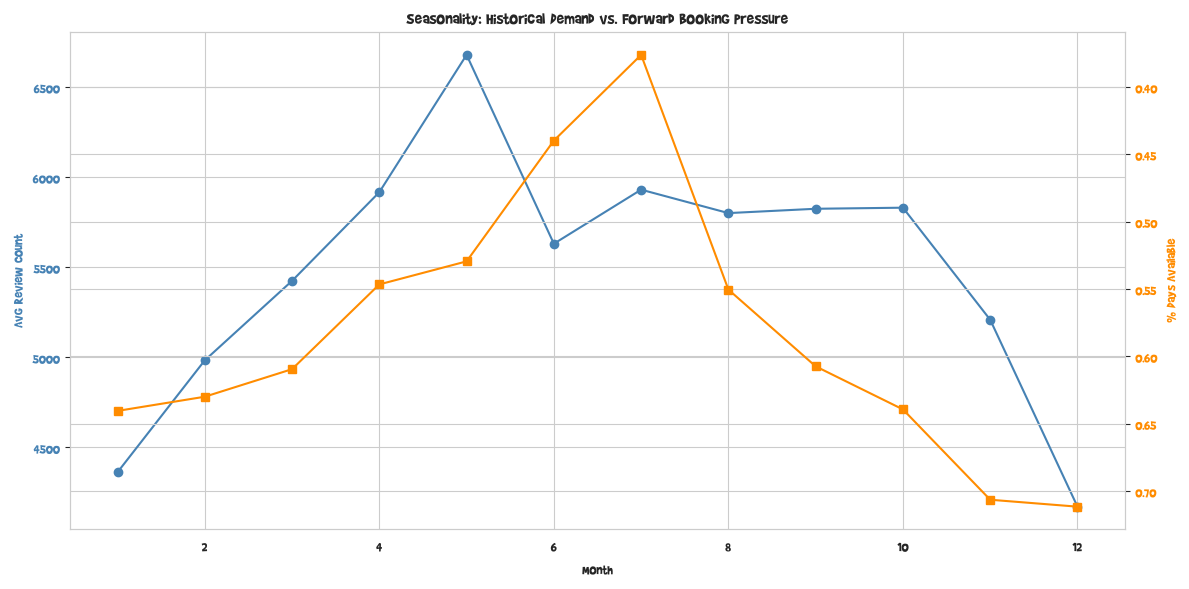

In [34]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(seasonality.index, seasonality.values, marker='o', color='steelblue', label='Avg Reviews (historical demand)')
ax1.set_xlabel("Month")
ax1.set_ylabel("Avg Review Count", color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(avail_by_month['month'], avail_by_month['pct_available'], marker='s', color='darkorange', label='Availability % (booking pressure)')
ax2.set_ylabel("% Days Available", color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.invert_yaxis()  # lower availability = higher demand, so invert for visual alignment

plt.title("Seasonality: Historical Demand vs. Forward Booking Pressure")
fig.tight_layout()
plt.savefig("../reports/figures/seasonality_dual.png", dpi=150)
plt.show()

## Host & Supply-Side Analysis (Section 4.4)

In [35]:
host_portfolio = con.execute("""
    SELECT 
        h.host_id,
        h.host_is_superhost,
        COUNT(l.listing_id) AS listing_count
    FROM dim_host h
    JOIN dim_listing l ON h.host_id = l.host_id
    GROUP BY h.host_id, h.host_is_superhost
    ORDER BY listing_count DESC
""").df()

print(f"Total unique hosts: {len(host_portfolio)}")
print(f"\nPortfolio size distribution:")
print(host_portfolio['listing_count'].describe())

print(f"\nSingle-listing hosts: {(host_portfolio['listing_count'] == 1).sum()} ({(host_portfolio['listing_count'] == 1).mean()*100:.1f}%)")
print(f"Hosts with 2-5 listings: {((host_portfolio['listing_count'] >= 2) & (host_portfolio['listing_count'] <= 5)).sum()}")
print(f"Hosts with 6-20 listings: {((host_portfolio['listing_count'] >= 6) & (host_portfolio['listing_count'] <= 20)).sum()}")
print(f"Hosts with 20+ listings: {(host_portfolio['listing_count'] > 20).sum()}")

print(f"\nTop 10 hosts by portfolio size:")
print(host_portfolio.head(10))

Total unique hosts: 4595

Portfolio size distribution:
count    4595.000000
mean        3.328183
std        15.320812
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       588.000000
Name: listing_count, dtype: float64

Single-listing hosts: 2988 (65.0%)
Hosts with 2-5 listings: 1146
Hosts with 6-20 listings: 375
Hosts with 20+ listings: 86

Top 10 hosts by portfolio size:
     host_id host_is_superhost  listing_count
0  346367515                 f            588
1    1447144                 f            448
2   21726991                 f            359
3   32037490                 f            293
4    4459553                 f            243
5  221480824                 f            243
6     299462                 f            140
7   36607755                 f            136
8  265193861                 f            125
9  158023606                 f            120


### Market concentration by listing share

In [36]:
host_portfolio_sorted = host_portfolio.sort_values('listing_count', ascending=False).reset_index(drop=True)
host_portfolio_sorted['cumulative_listings'] = host_portfolio_sorted['listing_count'].cumsum()
total_listings = host_portfolio_sorted['listing_count'].sum()
host_portfolio_sorted['cumulative_pct'] = host_portfolio_sorted['cumulative_listings'] / total_listings * 100

print(f"Total listings across all hosts: {total_listings}")
print(f"\n% of listings controlled by top N hosts:")
for n in [10, 50, 100, 500]:
    pct = host_portfolio_sorted.iloc[n-1]['cumulative_pct']
    print(f"  Top {n} hosts ({n/len(host_portfolio_sorted)*100:.1f}% of all hosts): {pct:.1f}% of all listings")

single_listing_share = (host_portfolio['listing_count'] == 1).sum() / total_listings * 100
print(f"\nSingle-listing hosts control: {single_listing_share:.1f}% of all listings")

Total listings across all hosts: 15293

% of listings controlled by top N hosts:
  Top 10 hosts (0.2% of all hosts): 17.6% of all listings
  Top 50 hosts (1.1% of all hosts): 30.1% of all listings
  Top 100 hosts (2.2% of all hosts): 37.4% of all listings
  Top 500 hosts (10.9% of all hosts): 61.1% of all listings

Single-listing hosts control: 19.5% of all listings


In [37]:
license_check = con.execute("""
    SELECT 
        CASE WHEN license IS NULL OR license = '' THEN 'No license listed' ELSE 'Has license' END AS license_status,
        COUNT(*) AS listing_count
    FROM stg_listings
    GROUP BY license_status
""").df()
print(license_check)
print(f"\nTotal listings: {license_check['listing_count'].sum()}")

      license_status  listing_count
0        Has license          12250
1  No license listed           3043

Total listings: 15293


In [38]:
license_dupes = con.execute("""
    SELECT license, COUNT(*) AS listings_using_this_license
    FROM stg_listings
    WHERE license IS NOT NULL AND license != ''
    GROUP BY license
    HAVING COUNT(*) > 1
    ORDER BY listings_using_this_license DESC
    LIMIT 10
""").df()
print(license_dupes)

unique_licenses = con.execute("""
    SELECT COUNT(DISTINCT license) AS unique_license_count
    FROM stg_listings
    WHERE license IS NOT NULL AND license != ''
""").df()
print(unique_licenses)

                                             license  \
0  Barcelona - Regional registration number<br />...   
1  Spain - National registration number<br />Exem...   
2  Spain - National registration number<br />ESFC...   
3  Barcelona - Regional registration number<br />...   
4  Barcelona - Regional registration number<br />...   
5  Barcelona - Regional registration number<br />...   
6  Spain - National registration number<br />ESFC...   
7  Barcelona - Regional registration number<br />...   
8  Barcelona - Regional registration number<br />...   
9  Barcelona - Regional registration number<br />...   

   listings_using_this_license  
0                          194  
1                          118  
2                           41  
3                           25  
4                           24  
5                           22  
6                           20  
7                           20  
8                           17  
9                           16  
   unique_license_co

In [39]:
pd.set_option('display.max_colwidth', None)
top_license_text = con.execute("""
    SELECT license, COUNT(*) AS n
    FROM stg_listings
    WHERE license IS NOT NULL AND license != ''
    GROUP BY license
    ORDER BY n DESC
    LIMIT 5
""").df()
for idx, row in top_license_text.iterrows():
    print(f"--- Count: {row['n']} ---")
    print(row['license'])
    print()

--- Count: 194 ---
Barcelona - Regional registration number<br />Exempt - seasonal rental

--- Count: 118 ---
Spain - National registration number<br />Exempt - tourist apartment<br /><br />Barcelona - Regional registration number<br />Exempt - seasonal rental

--- Count: 41 ---
Spain - National registration number<br />ESFCNT00000805900063465600000000000000000000000000001<br /><br />Barcelona - Regional registration number<br />Exempt - seasonal rental

--- Count: 25 ---
Barcelona - Regional registration number<br />Exempt - seasonal rental<br /><br />Spain - National registration number<br />Exempt - tourist apartment

--- Count: 24 ---
Barcelona - Regional registration number<br />HUTB012407



In [40]:
import re

listings_full = pd.read_parquet("../data/processed/listings_clean.parquet")

def classify_license(text):
    if pd.isna(text) or text == '':
        return 'no_license'
    if re.search(r'HUTB\d+', str(text)):
        return 'genuine_hut_number'
    if 'Exempt' in str(text):
        return 'exempt_declared'
    if re.search(r'ESFCNT\d+', str(text)):
        return 'genuine_national_number'
    return 'other'

listings_full['license_category'] = listings_full['license'].apply(classify_license)
print(listings_full['license_category'].value_counts())

genuine = listings_full[listings_full['license_category'] == 'genuine_hut_number']
print(f"\nUnique genuine HUTB numbers: {genuine['license'].nunique()}")

license_category
other                      6747
exempt_declared            3914
no_license                 3043
genuine_hut_number          983
genuine_national_number     606
Name: count, dtype: int64

Unique genuine HUTB numbers: 890


In [41]:
other_sample = listings_full[listings_full['license_category'] == 'other']['license'].dropna().head(10)
for val in other_sample:
    print(val[:150])
    print("---")

Spain - National registration number<br />ESFCTU000008058000039706000000000000000HUTB-002062349<br /><br />Barcelona - Regional registration number<br
---
Spain - National registration number<br />ESFCTU000008119000093652000000000000000HUTB-001506712<br /><br />Barcelona - Regional registration number<br
---
Barcelona - Regional registration number<br />HUTB-001282<br /><br />Spain - National registration number<br />ESFCTU000008054000280193000000000000000
---
Barcelona - Regional registration number<br />HUTB-001723<br /><br />Spain - National registration number<br />ESFCTU000008058000300011000000000000000
---
Barcelona - Regional registration number<br />HUTB-007966
---
Barcelona - Regional registration number<br />HUTB-002424<br /><br />Spain - National registration number<br />ESFCTU00000807300018946600000000000000H
---
Barcelona - Regional registration number<br />HUTB-000173<br /><br />Spain - National registration number<br />ESFCTU000008072000781281000000000000000
---
Spain - 

In [42]:
def classify_license_v2(text):
    if pd.isna(text) or text == '':
        return 'no_license'
    text = str(text)
    hutb_match = re.search(r'HUTB-?\d+', text)
    if hutb_match:
        return 'genuine_hut_number'
    if 'Exempt' in text:
        return 'exempt_declared'
    if re.search(r'ESFCNT\d+', text):
        return 'genuine_national_number'
    return 'other'

listings_full['license_category_v2'] = listings_full['license'].apply(classify_license_v2)
print(listings_full['license_category_v2'].value_counts())

def extract_hutb(text):
    if pd.isna(text):
        return None
    match = re.search(r'HUTB-?\d+', str(text))
    return match.group(0).replace('-', '') if match else None

listings_full['hutb_number'] = listings_full['license'].apply(extract_hutb)
genuine_v2 = listings_full[listings_full['hutb_number'].notna()]
print(f"\nListings with genuine HUTB number: {len(genuine_v2)}")
print(f"Unique HUTB numbers: {genuine_v2['hutb_number'].nunique()}")

# check remaining "other" bucket is now actually small/clean
still_other = listings_full[listings_full['license_category_v2'] == 'other']['license'].dropna().head(5)
print("\nRemaining 'other' samples:")
for val in still_other:
    print(val[:150])
    print("---")

license_category_v2
genuine_hut_number         7415
exempt_declared            3676
no_license                 3043
other                       646
genuine_national_number     513
Name: count, dtype: int64

Listings with genuine HUTB number: 7415
Unique HUTB numbers: 6437

Remaining 'other' samples:
Spain - National registration number<br />ESHFNT00000807200002789100100000000000000000000000001
---
Spain - National registration number<br />ESHFNT00000805600009410700200000000000000000000000006
---
Spain - National registration number<br />ESHFNT00000806600032689400100000000000000000000000009
---
Spain - National registration number<br />ESHFNT00000806300015064100200000000000000000000000000
---
Barcelona - Regional registration number<br />hutb-003607<br /><br />Spain - National registration number<br />ESFCTU000008054000290185000000000000000
---


In [43]:
superhost_compare = con.execute("""
    SELECT 
        h.host_is_superhost,
        COUNT(DISTINCT l.listing_id) AS listings,
        ROUND(AVG(f.price), 2) AS avg_price,
        ROUND(AVG(f.review_scores_rating), 3) AS avg_rating,
        ROUND(AVG(f.number_of_reviews), 1) AS avg_review_count
    FROM dim_host h
    JOIN dim_listing l ON h.host_id = l.host_id
    JOIN fact_listing_performance f ON l.listing_id = f.listing_id
    WHERE h.host_is_superhost IN ('t', 'f')
    GROUP BY h.host_is_superhost
""").df()
print(superhost_compare)

  host_is_superhost  listings  avg_price  avg_rating  avg_review_count
0                 f     11274     239.83       4.524              44.1
1                 t      3932     242.98       4.819             134.6


In [44]:
review_price = con.execute("""
    SELECT 
        f.listing_id,
        f.price,
        f.number_of_reviews,
        f.review_scores_rating,
        f.reviews_per_month
    FROM fact_listing_performance f
    JOIN v_listing_demand v ON f.listing_id = v.listing_id
    WHERE v.demand_segment = 'active' 
      AND f.price IS NOT NULL 
      AND f.review_scores_rating IS NOT NULL
""").df()

print(f"N = {len(review_price)}")
print(review_price[['price', 'number_of_reviews', 'review_scores_rating', 'reviews_per_month']].corr())

N = 9174
                         price  number_of_reviews  review_scores_rating  \
price                 1.000000           0.149565              0.073470   
number_of_reviews     0.149565           1.000000              0.122264   
review_scores_rating  0.073470           0.122264              1.000000   
reviews_per_month     0.098160           0.585958              0.095801   

                      reviews_per_month  
price                          0.098160  
number_of_reviews              0.585958  
review_scores_rating           0.095801  
reviews_per_month              1.000000  


In [45]:
high_vol_low_score = con.execute("""
    SELECT 
        f.listing_id,
        l.room_type,
        l.neighbourhood_name,
        f.price,
        f.number_of_reviews,
        f.review_scores_rating,
        f.review_scores_cleanliness,
        f.review_scores_location,
        f.review_scores_value
    FROM fact_listing_performance f
    JOIN dim_listing l ON f.listing_id = l.listing_id
    WHERE f.number_of_reviews >= 50
      AND f.review_scores_rating IS NOT NULL
      AND f.review_scores_rating < 4.0
    ORDER BY f.number_of_reviews DESC
""").df()

print(f"Listings with 50+ reviews but rating < 4.0: {len(high_vol_low_score)}")
print(high_vol_low_score.head(15))

Listings with 50+ reviews but rating < 4.0: 3
            listing_id        room_type    neighbourhood_name  price  \
0  1075918981611457806  Entire home/apt  el Putxet i el Farró   91.0   
1  1075925896005679821  Entire home/apt  el Putxet i el Farró   87.0   
2             34893410  Entire home/apt           el Poblenou  254.0   

   number_of_reviews  review_scores_rating  review_scores_cleanliness  \
0                125                  3.86                       4.19   
1                115                  3.86                       4.15   
2                 51                  3.96                       4.24   

   review_scores_location  review_scores_value  
0                    4.49                 3.81  
1                    4.37                 3.70  
2                    4.59                 3.73  


In [46]:
same_host_check = con.execute("""
    SELECT id AS listing_id, host_id
    FROM stg_listings
    WHERE id IN (1075918981611457806, 1075925896005679821, 34893410)
""").df()
print(same_host_check)

            listing_id    host_id
0             34893410    1683936
1  1075918981611457806  426483512
2  1075925896005679821  426483512


In [47]:
from scipy import stats

h1_data = con.execute("""
    SELECT l.room_type, f.price
    FROM fact_listing_performance f
    JOIN dim_listing l ON f.listing_id = l.listing_id
    JOIN v_listing_demand v ON f.listing_id = v.listing_id
    WHERE v.demand_segment = 'active' AND l.price_is_valid
      AND l.room_type IN ('Entire home/apt', 'Private room')
""").df()

entire = h1_data[h1_data['room_type'] == 'Entire home/apt']['price']
private = h1_data[h1_data['room_type'] == 'Private room']['price']

print(f"Entire home/apt: n={len(entire)}, mean={entire.mean():.2f}, median={entire.median():.2f}, std={entire.std():.2f}")
print(f"Private room: n={len(private)}, mean={private.mean():.2f}, median={private.median():.2f}, std={private.std():.2f}")

# Normality check (Shapiro on a sample, since full data likely too large for the test)
print(f"\nEntire home skewness: {stats.skew(entire):.2f}")
print(f"Private room skewness: {stats.skew(private):.2f}")

# Levene's test for equal variance
levene_stat, levene_p = stats.levene(entire, private)
print(f"\nLevene's test (equal variance): stat={levene_stat:.2f}, p={levene_p:.6f}")

Entire home/apt: n=7454, mean=263.86, median=240.10, std=189.46
Private room: n=1598, mean=105.40, median=92.00, std=85.06

Entire home skewness: 5.42
Private room skewness: 4.19

Levene's test (equal variance): stat=218.98, p=0.000000


In [48]:
u_stat, p_value = stats.mannwhitneyu(entire, private, alternative='greater')
print(f"Mann-Whitney U statistic: {u_stat:.0f}")
print(f"p-value: {p_value:.2e}")

# Effect size: rank-biserial correlation (appropriate for Mann-Whitney)
n1, n2 = len(entire), len(private)
r_rank_biserial = 1 - (2*u_stat) / (n1 * n2)
print(f"Rank-biserial correlation (effect size): {r_rank_biserial:.3f}")

# Also report median difference plainly for business interpretation
print(f"\nMedian price difference: €{entire.median() - private.median():.2f}")
print(f"Entire homes cost {(entire.median()/private.median() - 1)*100:.1f}% more (median basis)")

Mann-Whitney U statistic: 10093732
p-value: 0.00e+00
Rank-biserial correlation (effect size): -0.695

Median price difference: €148.10
Entire homes cost 161.0% more (median basis)


In [49]:
h2_data = con.execute("""
    SELECT h.host_is_superhost, f.review_scores_rating
    FROM dim_host h
    JOIN dim_listing l ON h.host_id = l.host_id
    JOIN fact_listing_performance f ON l.listing_id = f.listing_id
    WHERE h.host_is_superhost IN ('t', 'f') AND f.review_scores_rating IS NOT NULL
""").df()

superhost = h2_data[h2_data['host_is_superhost'] == 't']['review_scores_rating']
non_superhost = h2_data[h2_data['host_is_superhost'] == 'f']['review_scores_rating']

print(f"Superhost: n={len(superhost)}, mean={superhost.mean():.3f}, skew={stats.skew(superhost):.2f}")
print(f"Non-superhost: n={len(non_superhost)}, mean={non_superhost.mean():.3f}, skew={stats.skew(non_superhost):.2f}")

levene_stat2, levene_p2 = stats.levene(superhost, non_superhost)
print(f"Levene's test: stat={levene_stat2:.2f}, p={levene_p2:.6f}")

Superhost: n=3715, mean=4.819, skew=-6.97
Non-superhost: n=7966, mean=4.524, skew=-3.21
Levene's test: stat=655.41, p=0.000000


In [50]:
u_stat2, p_value2 = stats.mannwhitneyu(superhost, non_superhost, alternative='greater')
print(f"Mann-Whitney U statistic: {u_stat2:.0f}")
print(f"p-value: {p_value2:.2e}")

n1, n2 = len(superhost), len(non_superhost)
r_rank_biserial2 = 1 - (2*u_stat2) / (n1 * n2)
print(f"Rank-biserial correlation (effect size): {r_rank_biserial2:.3f}")

print(f"\nMedian superhost rating: {superhost.median():.2f}")
print(f"Median non-superhost rating: {non_superhost.median():.2f}")

Mann-Whitney U statistic: 21271370
p-value: 0.00e+00
Rank-biserial correlation (effect size): -0.438

Median superhost rating: 4.86
Median non-superhost rating: 4.63


In [51]:
h3_data = con.execute("""
    SELECT f.number_of_reviews, f.price
    FROM fact_listing_performance f
    JOIN v_listing_demand v ON f.listing_id = v.listing_id
    WHERE v.demand_segment = 'active' AND f.price IS NOT NULL
""").df()

high_reviews = h3_data[h3_data['number_of_reviews'] > 10]['price']
low_reviews = h3_data[h3_data['number_of_reviews'] <= 10]['price']

print(f"10+ reviews: n={len(high_reviews)}, mean={high_reviews.mean():.2f}, median={high_reviews.median():.2f}")
print(f"<=10 reviews: n={len(low_reviews)}, mean={low_reviews.mean():.2f}, median={low_reviews.median():.2f}")
print(f"\nSkew high: {stats.skew(high_reviews):.2f}, Skew low: {stats.skew(low_reviews):.2f}")

levene_stat3, levene_p3 = stats.levene(high_reviews, low_reviews)
print(f"Levene's: stat={levene_stat3:.2f}, p={levene_p3:.6f}")


10+ reviews: n=6480, mean=266.43, median=246.74
<=10 reviews: n=2694, mean=157.13, median=106.67

Skew high: 2.53, Skew low: 8.97
Levene's: stat=22.72, p=0.000002


In [52]:
u_stat3, p_value3 = stats.mannwhitneyu(high_reviews, low_reviews, alternative='two-sided')
print(f"Mann-Whitney U: {u_stat3:.0f}")
print(f"p-value: {p_value3:.2e}")

n1, n2 = len(high_reviews), len(low_reviews)
r_rank_biserial3 = 1 - (2*u_stat3) / (n1 * n2)
print(f"Effect size (rank-biserial): {abs(r_rank_biserial3):.3f}")
print(f"\nMedian price difference: €{high_reviews.median() - low_reviews.median():.2f}")
print(f"Ratio: {high_reviews.median()/low_reviews.median():.2f}x")

Mann-Whitney U: 13480184
p-value: 0.00e+00
Effect size (rank-biserial): 0.544

Median price difference: €140.06
Ratio: 2.31x


In [53]:
h4_data = con.execute("""
    SELECT n.neighbourhood_group, f.price
    FROM fact_listing_performance f
    JOIN dim_listing l ON f.listing_id = l.listing_id
    JOIN dim_neighbourhood n ON l.neighbourhood_name = n.neighbourhood_name
    JOIN v_listing_demand v ON f.listing_id = v.listing_id
    WHERE v.demand_segment = 'active' AND l.price_is_valid
    GROUP BY n.neighbourhood_group, f.price, f.listing_id
    ORDER BY n.neighbourhood_group
""").df()

print(f"Neighbourhood groups: {h4_data['neighbourhood_group'].nunique()}")
print(f"\nGroup sizes and medians:")
print(h4_data.groupby('neighbourhood_group')['price'].agg(['count','median','mean','std']).round(2))

print(f"\nSkewness by group:")
print(h4_data.groupby('neighbourhood_group')['price'].apply(stats.skew).round(2))

Neighbourhood groups: 10

Group sizes and medians:
                     count  median    mean     std
neighbourhood_group                               
Ciutat Vella          1784  125.00  176.35  173.93
Eixample              3703  257.50  282.48  207.36
Gràcia                 863  217.00  222.00  126.92
Horta-Guinardó         193  165.50  187.48  182.06
Les Corts              205  193.18  205.89  151.70
Nou Barris              48   79.94  105.65   81.15
Sant Andreu            101   92.00  143.66  146.35
Sant Martí             901  230.00  239.80  165.12
Sants-Montjuïc         957  201.00  202.10  155.18
Sarrià-Sant Gervasi    419  196.00  215.07  148.50

Skewness by group:
neighbourhood_group
Ciutat Vella            6.27
Eixample                4.75
Gràcia                  1.31
Horta-Guinardó          3.78
Les Corts               5.41
Nou Barris              1.24
Sant Andreu             5.69
Sant Martí              3.07
Sants-Montjuïc         11.86
Sarrià-Sant Gervasi     2.69
Name: p

In [54]:
from scipy.stats import kruskal
import itertools

# Kruskal-Wallis test
groups = [group['price'].values for name, group in h4_data.groupby('neighbourhood_group')]
kw_stat, kw_p = kruskal(*groups)
print(f"Kruskal-Wallis H={kw_stat:.2f}, p={kw_p:.2e}")

# Eta-squared effect size for Kruskal-Wallis
n_total = len(h4_data)
k = h4_data['neighbourhood_group'].nunique()
eta_squared = (kw_stat - k + 1) / (n_total - k)
print(f"Eta-squared (effect size): {eta_squared:.3f}")

# Dunn's post-hoc with Bonferroni correction (manual implementation)
group_names = h4_data['neighbourhood_group'].unique()
pairs = list(itertools.combinations(group_names, 2))
n_comparisons = len(pairs)
print(f"\nTotal pairwise comparisons: {n_comparisons}")
print(f"Bonferroni-corrected alpha: {0.05/n_comparisons:.4f}")

# Run pairwise Mann-Whitney with Bonferroni correction
results = []
for g1, g2 in pairs:
    d1 = h4_data[h4_data['neighbourhood_group'] == g1]['price']
    d2 = h4_data[h4_data['neighbourhood_group'] == g2]['price']
    u, p = stats.mannwhitneyu(d1, d2, alternative='two-sided')
    p_corrected = min(p * n_comparisons, 1.0)
    results.append({
        'group1': g1, 'group2': g2,
        'median1': d1.median(), 'median2': d2.median(),
        'p_raw': p, 'p_bonferroni': p_corrected,
        'significant': p_corrected < 0.05
    })

results_df = pd.DataFrame(results)
sig_pairs = results_df[results_df['significant']]
non_sig_pairs = results_df[~results_df['significant']]
print(f"\nSignificant pairs (Bonferroni-corrected): {len(sig_pairs)} of {n_comparisons}")
print(f"Non-significant pairs: {len(non_sig_pairs)}")
print("\nNon-significant pairs (where groups do NOT differ):")
print(non_sig_pairs[['group1','group2','median1','median2','p_bonferroni']].to_string())

Kruskal-Wallis H=883.72, p=1.99e-184
Eta-squared (effect size): 0.095

Total pairwise comparisons: 45
Bonferroni-corrected alpha: 0.0011

Significant pairs (Bonferroni-corrected): 33 of 45
Non-significant pairs: 12

Non-significant pairs (where groups do NOT differ):
            group1               group2  median1  median2  p_bonferroni
2     Ciutat Vella       Horta-Guinardó   125.00   165.50      1.000000
5     Ciutat Vella          Sant Andreu   125.00    92.00      0.678694
18          Gràcia            Les Corts   217.00   193.18      0.753545
21          Gràcia           Sant Martí   217.00   230.00      1.000000
23          Gràcia  Sarrià-Sant Gervasi   217.00   196.00      1.000000
24  Horta-Guinardó            Les Corts   165.50   193.18      0.342124
26  Horta-Guinardó          Sant Andreu   165.50    92.00      1.000000
33       Les Corts       Sants-Montjuïc   193.18   201.00      1.000000
34       Les Corts  Sarrià-Sant Gervasi   193.18   196.00      1.000000
35      Nou 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_30988\9763566.py:33: UserWarning: Glyph 951 (\N{GREEK SMALL LETTER ETA}) missing from font(s) Brady Bunch.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_30988\9763566.py:34: UserWarning: Glyph 951 (\N{GREEK SMALL LETTER ETA}) missing from font(s) Brady Bunch.
  plt.savefig("../reports/figures/neighbourhood_price_tiers.png", dpi=150)
c:\Users\ASUS\Downloads\EXPERNETIC\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 951 (\N{GREEK SMALL LETTER ETA}) missing from font(s) Brady Bunch.
  fig.canvas.print_figure(bytes_io, **kw)


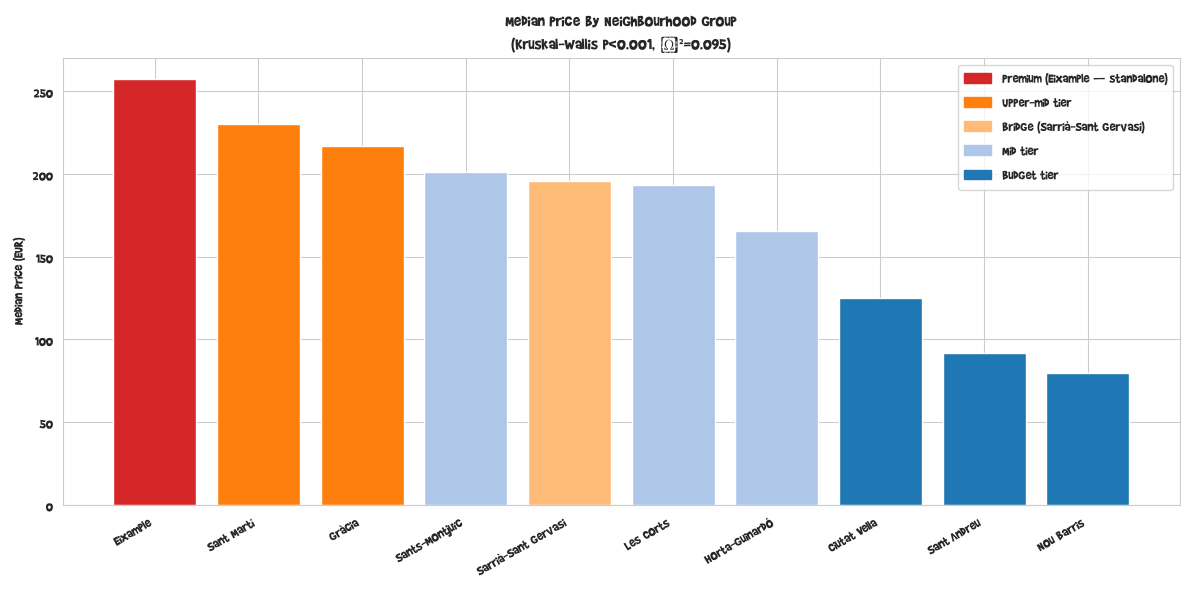

In [55]:
import matplotlib.patches as mpatches

tier_colors = {
    'Eixample': '#d62728',
    'Sant Martí': '#ff7f0e',
    'Gràcia': '#ff7f0e',
    'Sarrià-Sant Gervasi': '#ffbb78',
    'Les Corts': '#aec7e8',
    'Sants-Montjuïc': '#aec7e8',
    'Horta-Guinardó': '#aec7e8',
    'Ciutat Vella': '#1f77b4',
    'Sant Andreu': '#1f77b4',
    'Nou Barris': '#1f77b4'
}

summary = h4_data.groupby('neighbourhood_group')['price'].median().sort_values(ascending=False)
colors = [tier_colors[g] for g in summary.index]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(summary.index, summary.values, color=colors)
ax.set_title("Median Price by Neighbourhood Group\n(Kruskal-Wallis p<0.001, η²=0.095)")
ax.set_ylabel("Median Price (EUR)")
plt.xticks(rotation=30, ha='right')

patches = [
    mpatches.Patch(color='#d62728', label='Premium (Eixample — standalone)'),
    mpatches.Patch(color='#ff7f0e', label='Upper-mid tier'),
    mpatches.Patch(color='#ffbb78', label='Bridge (Sarrià-Sant Gervasi)'),
    mpatches.Patch(color='#aec7e8', label='Mid tier'),
    mpatches.Patch(color='#1f77b4', label='Budget tier')
]
ax.legend(handles=patches, loc='upper right')
plt.tight_layout()
plt.savefig("../reports/figures/neighbourhood_price_tiers.png", dpi=150)
plt.show()

In [56]:
h5_data = con.execute("""
    SELECT 
        d.is_weekend,
        AVG(CASE WHEN c.available THEN 1.0 ELSE 0.0 END) AS pct_available,
        COUNT(*) AS n_observations
    FROM fact_calendar c
    JOIN dim_date d ON c.date = d.date
    GROUP BY d.is_weekend
""").df()
print(h5_data)

# Pull raw availability for the actual test
h5_raw = con.execute("""
    SELECT 
        d.is_weekend,
        CASE WHEN c.available THEN 1 ELSE 0 END AS available
    FROM fact_calendar c
    JOIN dim_date d ON c.date = d.date
""").df()

weekend = h5_raw[h5_raw['is_weekend'] == True]['available']
weekday = h5_raw[h5_raw['is_weekend'] == False]['available']

print(f"\nWeekend observations: {len(weekend):,}")
print(f"Weekday observations: {len(weekday):,}")
print(f"Weekend availability rate: {weekend.mean():.4f}")
print(f"Weekday availability rate: {weekday.mean():.4f}")

   is_weekend  pct_available  n_observations
0       False       0.583169         3991473
1        True       0.579319         1590472

Weekend observations: 1,590,472
Weekday observations: 3,991,473
Weekend availability rate: 0.5793
Weekday availability rate: 0.5832


In [57]:
from scipy.stats import chi2_contingency
import numpy as np

# Chi-square test on availability proportions
# (binary outcome + large n = chi-square is appropriate here)
weekend_available = weekend.sum()
weekend_unavailable = len(weekend) - weekend_available
weekday_available = weekday.sum()
weekday_unavailable = len(weekday) - weekday_available

contingency = np.array([
    [weekend_available, weekend_unavailable],
    [weekday_available, weekday_unavailable]
])

chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-square statistic: {chi2:.2f}")
print(f"p-value: {p:.2e}")
print(f"Degrees of freedom: {dof}")

# Effect size: Cramer's V
n_total = contingency.sum()
cramers_v = np.sqrt(chi2 / (n_total * (min(contingency.shape) - 1)))
print(f"Cramer's V (effect size): {cramers_v:.4f}")

print(f"\nWeekend availability: {weekend.mean()*100:.2f}%")
print(f"Weekday availability: {weekday.mean()*100:.2f}%")
print(f"Absolute difference: {abs(weekend.mean() - weekday.mean())*100:.2f} percentage points")

Chi-square statistic: 69.29
p-value: 8.51e-17
Degrees of freedom: 1
Cramer's V (effect size): 0.0035

Weekend availability: 57.93%
Weekday availability: 58.32%
Absolute difference: 0.39 percentage points
